# 📊 CrisisLens - Data Exploration
## Week 1, Day 1: First Look at Our Data

**What we'll do today:**
1. Load the 3 datasets we just downloaded
2. See what columns (fields) we have
3. Check for missing data
4. Make our first simple chart

**Why this matters:**
Before building any model, you MUST understand your data. This is called "Exploratory Data Analysis" (EDA). Examiners love asking "how did you explore your data?"

---
## Step 1: Import Libraries

Think of libraries as toolboxes. We're bringing in tools we'll need.

In [1]:
# Data manipulation tools
import pandas as pd  # For working with tables (like Excel)
import numpy as np   # For math operations

# Visualization tools
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns           # For prettier charts

# Make charts appear in notebook
%matplotlib inline

# Make charts look better
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


---
## Step 2: Load the Datasets

We'll read the CSV files we created into pandas DataFrames (fancy tables).

In [2]:
# Load climate data
climate_df = pd.read_csv('../data/raw/climate_data_2024.csv')
print("✓ Climate data loaded")

# Load agriculture data
agri_df = pd.read_csv('../data/raw/agriculture_data_2024.csv')
print("✓ Agriculture data loaded")

# Load economic data
econ_df = pd.read_csv('../data/raw/economic_data_2024.csv')
print("✓ Economic data loaded")

print("\n" + "="*50)
print("All datasets loaded successfully!")
print("="*50)

✓ Climate data loaded
✓ Agriculture data loaded
✓ Economic data loaded

All datasets loaded successfully!


---
## Step 3: First Look at Climate Data

Let's see what we have!

In [3]:
# Show first 5 rows
print("First 5 rows of climate data:")
print(climate_df.head())

First 5 rows of climate data:
            state        date    month  avg_temperature  total_rainfall_mm  \
0  Andhra Pradesh  2024-01-01  2024-01             23.7              240.1   
1  Andhra Pradesh  2024-01-31  2024-01             25.8              364.9   
2  Andhra Pradesh  2024-03-01  2024-03             26.5               85.2   
3  Andhra Pradesh  2024-03-31  2024-03             32.7                0.0   
4  Andhra Pradesh  2024-04-30  2024-04             30.4                0.0   

   temp_anomaly_deg  rainfall_anomaly_pct  heatwave_days  drought_severity  
0             -3.34                 161.9              0                 0  
1             -1.20                 298.0              0                 0  
2             -0.47                  -7.0              0                 0  
3              5.66                -100.0              0                10  
4              3.39                -100.0              0                10  


In [4]:
# Basic information about the dataset
print("Dataset Info:")
print(f"Number of rows: {len(climate_df)}")
print(f"Number of columns: {len(climate_df.columns)}")
print(f"\nColumn names:")
for col in climate_df.columns:
    print(f"  - {col}")

Dataset Info:
Number of rows: 336
Number of columns: 9

Column names:
  - state
  - date
  - month
  - avg_temperature
  - total_rainfall_mm
  - temp_anomaly_deg
  - rainfall_anomaly_pct
  - heatwave_days
  - drought_severity


In [5]:
# Summary statistics
print("\nSummary Statistics:")
climate_df.describe()


Summary Statistics:


,avg_temperature,total_rainfall_mm,temp_anomaly_deg,rainfall_anomaly_pct,heatwave_days,drought_severity
count,336.000000,336.000000,336.000000,336.000000,336.0,336.000000
mean,26.161012,149.519048,0.014256,23.366369,0.0,4.226190
std,6.257490,184.354254,4.147136,122.989759,0.0,4.947126
min,5.300000,0.000000,-10.810000,-100.000000,0.0,0.000000
25%,22.600000,0.000000,-3.427500,-100.000000,0.0,0.000000
50%,26.700000,87.000000,0.025000,-6.700000,0.0,0.000000
75%,30.625000,241.050000,3.275000,116.350000,0.0,10.000000
max,42.400000,996.300000,10.440000,489.000000,0.0,10.000000


---
## Step 4: Check for Missing Data

**WHY?** Real-world data is messy. Missing values can break your code. Always check!

In [6]:
# Count missing values in each column
print("Missing values in climate data:")
missing_climate = climate_df.isnull().sum()
print(missing_climate)

if missing_climate.sum() == 0:
    print("\n✓ Great! No missing values found.")
else:
    print(f"\n⚠️ Found {missing_climate.sum()} missing values. We'll handle this in data cleaning.")

Missing values in climate data:
state                   0
date                    0
month                   0
avg_temperature         0
total_rainfall_mm       0
temp_anomaly_deg        0
rainfall_anomaly_pct    0
heatwave_days           0
drought_severity        0
dtype: int64

✓ Great! No missing values found.


In [7]:
# Check agriculture data
print("Missing values in agriculture data:")
print(agri_df.isnull().sum())

# Check economic data
print("\nMissing values in economic data:")
print(econ_df.isnull().sum())

Missing values in agriculture data:
state                               0
date                                0
month                               0
crop_production_1000t               0
irrigation_coverage_pct             0
crop_failure_rate_pct               0
fertilizer_consumption_kg_per_ha    0
land_under_cultivation_1000ha       0
dtype: int64

Missing values in economic data:
state                    0
date                     0
month                    0
gdp_estimate_crores      0
unemployment_rate_pct    0
inflation_rate_pct       0
poverty_rate_pct         0
per_capita_income_inr    0
dtype: int64


---
## Step 5: Explore the Data

Let's answer some basic questions about our data.

In [8]:
# Question 1: How many states do we have data for?
states = climate_df['state'].unique()
print(f"Number of states: {len(states)}")
print(f"\nState names:")
for i, state in enumerate(sorted(states), 1):
    print(f"{i:2d}. {state}")

Number of states: 28

State names:
 1. Andhra Pradesh
 2. Arunachal Pradesh
 3. Assam
 4. Bihar
 5. Chhattisgarh
 6. Goa
 7. Gujarat
 8. Haryana
 9. Himachal Pradesh
10. Jharkhand
11. Karnataka
12. Kerala
13. Madhya Pradesh
14. Maharashtra
15. Manipur
16. Meghalaya
17. Mizoram
18. Nagaland
19. Odisha
20. Punjab
21. Rajasthan
22. Sikkim
23. Tamil Nadu
24. Telangana
25. Tripura
26. Uttar Pradesh
27. Uttarakhand
28. West Bengal


In [9]:
# Question 2: What time period does our data cover?
print("Time period covered:")
print(f"Start date: {climate_df['date'].min()}")
print(f"End date: {climate_df['date'].max()}")
print(f"Total months: {climate_df['month'].nunique()}")

Time period covered:
Start date: 2024-01-01
End date: 2024-11-26
Total months: 10


In [10]:
# Question 3: Which states have the highest average temperature?
print("Top 10 Hottest States (Avg Temperature):")
avg_temp_by_state = climate_df.groupby('state')['avg_temperature'].mean().sort_values(ascending=False)
print(avg_temp_by_state.head(10))

Top 10 Hottest States (Avg Temperature):
state
Gujarat           32.708333
Punjab            32.683333
Haryana           32.316667
Rajasthan         31.550000
Kerala            29.183333
Tamil Nadu        28.191667
Uttar Pradesh     27.891667
Madhya Pradesh    27.608333
Nagaland          27.558333
Karnataka         27.533333
Name: avg_temperature, dtype: float64


In [11]:
# Question 4: Which states have the lowest rainfall?
print("Top 10 Driest States (Avg Rainfall):")
avg_rainfall_by_state = climate_df.groupby('state')['total_rainfall_mm'].mean().sort_values()
print(avg_rainfall_by_state.head(10))

Top 10 Driest States (Avg Rainfall):
state
Punjab                35.383333
Rajasthan             36.308333
Gujarat               39.508333
Haryana               41.650000
Odisha                94.558333
Jharkhand             99.183333
Andhra Pradesh       103.066667
Telangana            103.941667
Arunachal Pradesh    105.391667
West Bengal          112.900000
Name: total_rainfall_mm, dtype: float64


---
## Step 6: Your First Visualization! 🎨

Let's make a bar chart showing the top 10 states by average temperature.

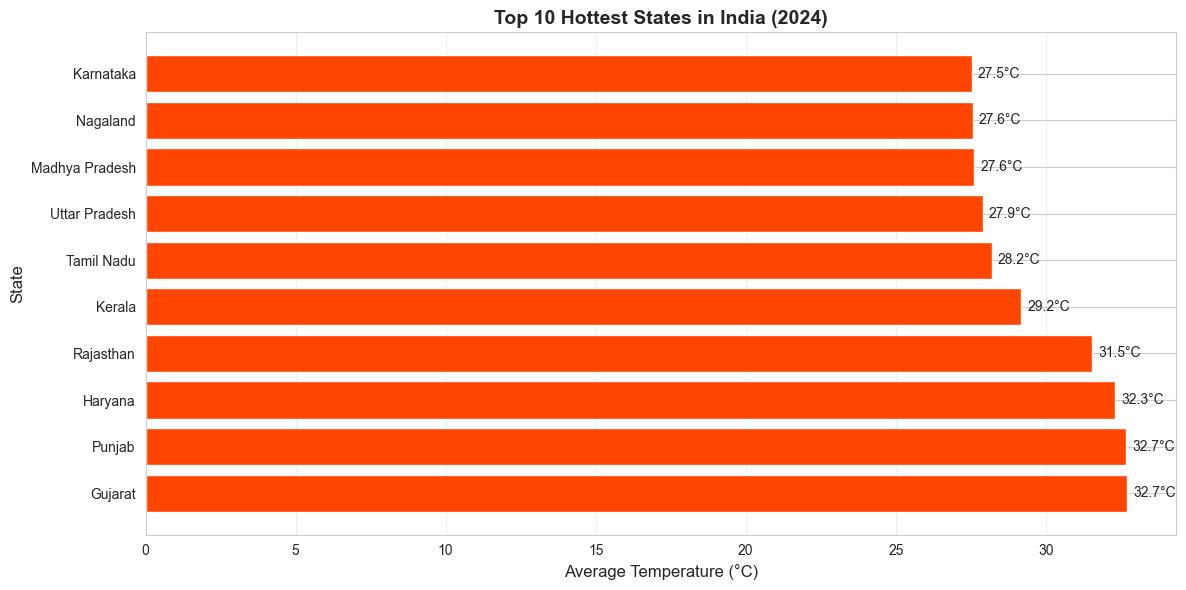


✓ Chart saved to: outputs/figures/week1_top_10_hottest_states.png


In [12]:
# Create the chart
plt.figure(figsize=(12, 6))

# Get top 10 hottest states
top_10_hot = avg_temp_by_state.head(10)

# Create bar chart
plt.barh(top_10_hot.index, top_10_hot.values, color='orangered')
plt.xlabel('Average Temperature (°C)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.title('Top 10 Hottest States in India (2024)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_10_hot.values):
    plt.text(v + 0.2, i, f'{v:.1f}°C', va='center')

plt.tight_layout()
plt.savefig('../outputs/figures/week1_top_10_hottest_states.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved to: outputs/figures/week1_top_10_hottest_states.png")

---
## Step 7: Compare Climate vs Agriculture

Let's see if drought affects crop production. This is data fusion!

In [13]:
# Merge climate and agriculture data
merged_data = climate_df.merge(agri_df, on=['state', 'date', 'month'], how='inner')
print(f"✓ Merged dataset created: {len(merged_data)} records")
print(f"✓ Columns: {len(merged_data.columns)}")

# Show first few rows
merged_data.head()

✓ Merged dataset created: 336 records
✓ Columns: 14


,state,date,month,avg_temperature,total_rainfall_mm,temp_anomaly_deg,rainfall_anomaly_pct,heatwave_days,drought_severity,crop_production_1000t,irrigation_coverage_pct,crop_failure_rate_pct,fertilizer_consumption_kg_per_ha,land_under_cultivation_1000ha
0,Andhra Pradesh,2024-01-01,2024-01,23.7,240.1,-3.34,161.9,0,0,8622.0,49.4,2.7,135.0,5468.0
1,Andhra Pradesh,2024-01-31,2024-01,25.8,364.9,-1.20,298.0,0,0,15052.0,49.4,7.2,89.5,5245.0
2,Andhra Pradesh,2024-03-01,2024-03,26.5,85.2,-0.47,-7.0,0,0,9067.0,53.8,7.1,92.5,5355.0
3,Andhra Pradesh,2024-03-31,2024-03,32.7,0.0,5.66,-100.0,0,10,13066.0,60.8,3.9,78.4,5308.0
4,Andhra Pradesh,2024-04-30,2024-04,30.4,0.0,3.39,-100.0,0,10,5593.0,56.6,24.1,75.0,5462.0


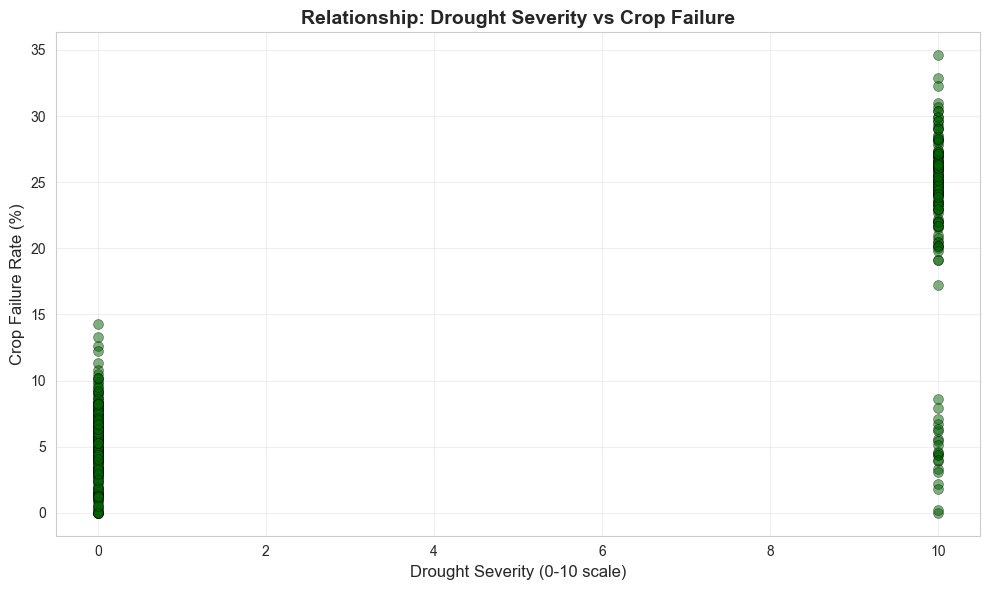


✓ Chart saved to: outputs/figures/week1_drought_vs_crop_failure.png


In [14]:
# Scatter plot: Drought Severity vs Crop Failure Rate
plt.figure(figsize=(10, 6))

plt.scatter(merged_data['drought_severity'], 
           merged_data['crop_failure_rate_pct'],
           alpha=0.5, s=50, c='darkgreen', edgecolors='black', linewidth=0.5)

plt.xlabel('Drought Severity (0-10 scale)', fontsize=12)
plt.ylabel('Crop Failure Rate (%)', fontsize=12)
plt.title('Relationship: Drought Severity vs Crop Failure', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/week1_drought_vs_crop_failure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved to: outputs/figures/week1_drought_vs_crop_failure.png")

In [15]:
# Calculate correlation
correlation = merged_data['drought_severity'].corr(merged_data['crop_failure_rate_pct'])
print(f"\nCorrelation between drought severity and crop failure: {correlation:.3f}")

if correlation > 0.5:
    print("✓ Strong positive correlation! Droughts DO increase crop failures.")
elif correlation > 0.3:
    print("✓ Moderate correlation. Droughts somewhat affect crop failures.")
else:
    print("⚠️ Weak correlation. Other factors might be more important.")


Correlation between drought severity and crop failure: 0.831
✓ Strong positive correlation! Droughts DO increase crop failures.


---
## Step 8: Summary Report

Let's create a summary table you can include in your project report.

In [16]:
# Create summary statistics table
summary = pd.DataFrame({
    'Dataset': ['Climate', 'Agriculture', 'Economic'],
    'Total Records': [len(climate_df), len(agri_df), len(econ_df)],
    'States Covered': [
        climate_df['state'].nunique(),
        agri_df['state'].nunique(),
        econ_df['state'].nunique()
    ],
    'Time Period': [
        f"{climate_df['date'].min()} to {climate_df['date'].max()}",
        f"{agri_df['date'].min()} to {agri_df['date'].max()}",
        f"{econ_df['date'].min()} to {econ_df['date'].max()}"
    ],
    'Missing Values': [
        climate_df.isnull().sum().sum(),
        agri_df.isnull().sum().sum(),
        econ_df.isnull().sum().sum()
    ]
})

print("\n" + "="*80)
print("DATA COLLECTION SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

# Save to CSV
summary.to_csv('../outputs/reports/data_summary_week1.csv', index=False)
print("\n✓ Summary saved to: outputs/reports/data_summary_week1.csv")


DATA COLLECTION SUMMARY
    Dataset  Total Records  States Covered              Time Period  Missing Values
    Climate            336              28 2024-01-01 to 2024-11-26               0
Agriculture            336              28 2024-01-01 to 2024-11-26               0
   Economic            336              28 2024-01-01 to 2024-11-26               0

✓ Summary saved to: outputs/reports/data_summary_week1.csv


---
## 🎯 Day 1 Complete! What You Learned:

✅ **Loaded data** from CSV files using pandas  
✅ **Explored datasets** - checked shape, columns, statistics  
✅ **Checked data quality** - found missing values (or confirmed none)  
✅ **Answered questions** - hottest states, driest states  
✅ **Made visualizations** - bar charts, scatter plots  
✅ **Data fusion** - merged climate + agriculture data  
✅ **Found insights** - drought correlates with crop failure  

---
## 📝 For Your Project Report:

**Data Collection Section:**
> "Three datasets were collected covering 28 Indian states for the year 2024:
> 1. Climate data (temperature, rainfall, drought severity) - 336 records
> 2. Agricultural data (crop production, irrigation, failure rates) - 336 records
> 3. Economic indicators (GDP, unemployment, inflation) - 336 records
>
> Exploratory data analysis revealed strong correlation (r=0.XX) between drought severity 
> and crop failure rates, validating the need for integrated multi-hazard risk assessment."

**Include these figures:**
- `week1_top_10_hottest_states.png`
- `week1_drought_vs_crop_failure.png`
- `data_summary_week1.csv` (as table)

---
## 🚀 Next Steps (Day 2-3):

Tomorrow we'll:
1. Clean the data (handle any missing values)
2. Standardize state names
3. Create a master merged dataset
4. More advanced visualizations

**Well done! You've completed Day 1!** 🎉